# Mock Dataset

In [22]:
# We predefine the thresholds for burnout risk levels
threshold_dict = {
    "HIGH": 0.7,
    "MEDIUM": 0.5,
}

In [29]:
import pandas as pd
import numpy as np

# 1. Setup Timeline
days = np.arange(1, 121)  # Simulate 120 days
stress_levels = []

# 2. Generate Synthetic "User Journey" with doubled phase durations
for day in days:
    if day <= 28:
        # Phase 1: Healthy Baseline (Low Stress)
        val = np.random.uniform(0.0, 0.1)
    elif 29 <= day <= 36:
        # Phase 2: The Sudden Spiral (Acute Spike)
        val = np.random.uniform(0.85, 0.95)
    elif 37 <= day <= 90:
        # Phase 3: Chronic Fatigue (Sustained High Stress)
        val = np.random.uniform(0.6, 0.85)
    elif 91 <= day <= 102:
        # Phase 4: Recovery (Declining Stress)
        val = np.random.uniform(0.4, 0.6)
    else:
        # Phase 5: Continued Recovery (Low Stress)
        val = np.random.uniform(0.1, 0.3)
    stress_levels.append(round(val, 3))

# 3. Create DataFrame
mock_data_1 = pd.DataFrame({
    'day': days,
    'predicted_stress': stress_levels
})

# 4. Display for Verification
print(mock_data_1.head(15))

# Test

    day  predicted_stress
0     1             0.080
1     2             0.095
2     3             0.096
3     4             0.049
4     5             0.091
5     6             0.051
6     7             0.050
7     8             0.055
8     9             0.002
9    10             0.088
10   11             0.002
11   12             0.057
12   13             0.003
13   14             0.002
14   15             0.033


# Prediction of Burnout Risk Over Time

## Define functions

In [24]:
def calculate_alpha(n, tail_weight=0.05):
    # (1-alpha)^n = tail_weight
    alpha = 1 - (tail_weight ** (1/n))
    return round(alpha, 3)


def calculate_single_ema(new_prediction, prev_ema=None, n=28):

    alpha = calculate_alpha(n)
    
    if prev_ema is None:
        return new_prediction
    
    # Standard EMA Formula
    current_ema = (new_prediction * alpha) + (prev_ema * (1 - alpha))
    return round(current_ema, 3)

def calculate_dual_ema(new_prediction, prev_short_ema=None, prev_long_ema=None, short_n=7, long_n=28):
    
    if prev_short_ema is None:
        short_ema = new_prediction
    else:
        short_ema = calculate_single_ema(new_prediction, prev_short_ema, n=short_n)
    
    if prev_long_ema is None:
        long_ema = new_prediction
    else:
        long_ema = calculate_single_ema(new_prediction, prev_long_ema, n=long_n)
    
    return short_ema, long_ema

def calculate_confidence(sigma, n, confidence_level=0.90):

    # Calculate standard error of the mean (SEM) for the confidence interval
    alpha = calculate_alpha(n)
    SEM = sigma * np.sqrt(alpha/(2-alpha))

    # Z-scores for common confidence levels
    z_scores = {
        0.90: 1.645,
        0.95: 1.96,
        0.99: 2.576
    }
    
    z = z_scores.get(confidence_level, 1.645)  # Default to 90% if not specified
    confidence_interval = z * SEM
    return round(confidence_interval, 3)

## Plot short and long EMAs

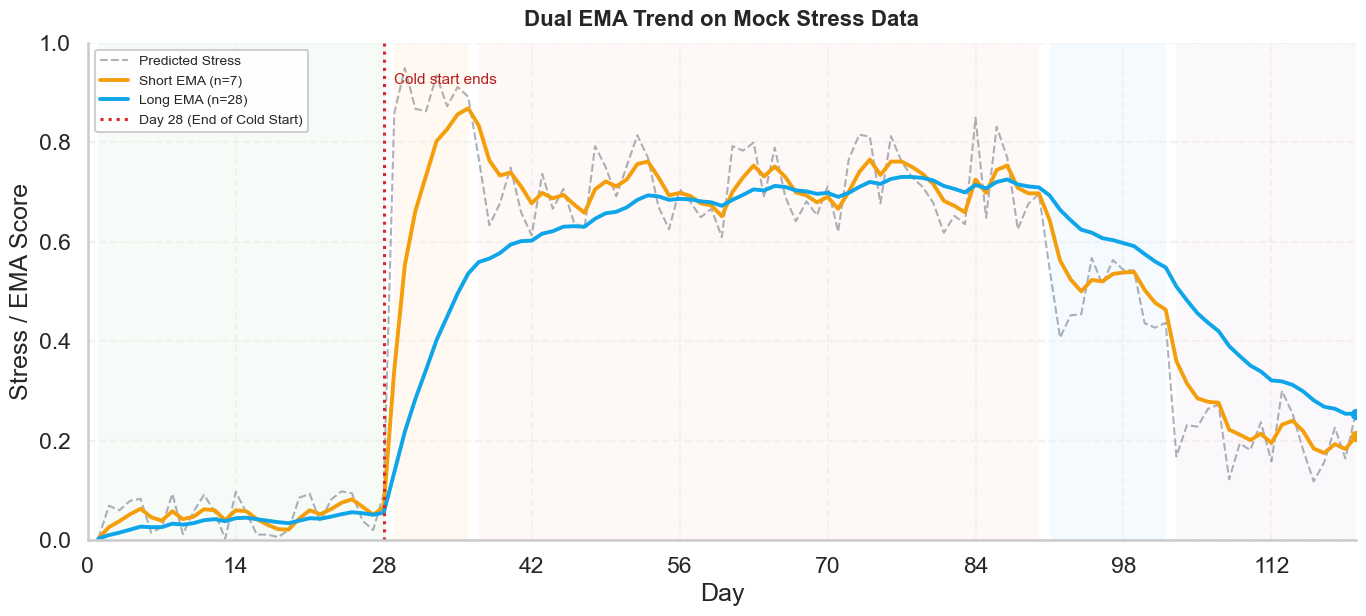

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Use a cleaner plotting style
sns.set_theme(style='whitegrid', context='talk')

# Use mock_data_1 and calculate dual EMA (short-term + long-term)
short_n = 7
long_n = 28

short_ema_values = []
long_ema_values = []
prev_short_ema = None
prev_long_ema = None

for _, row in mock_data_1.iterrows():
    new_pred = row['predicted_stress']
    short_ema, long_ema = calculate_dual_ema(
        new_pred,
        prev_short_ema=prev_short_ema,
        prev_long_ema=prev_long_ema,
        short_n=short_n,
        long_n=long_n
    )
    short_ema_values.append(short_ema)
    long_ema_values.append(long_ema)
    prev_short_ema = short_ema
    prev_long_ema = long_ema

# Save results back into the mock dataframe
mock_data_1['short_ema'] = short_ema_values
mock_data_1['long_ema'] = long_ema_values

# Plot both EMA lines with improved styling
fig, ax = plt.subplots(figsize=(14, 6.5))

# Soft phase shading to make the journey easier to read
ax.axvspan(1, 28, color='#E8F5E9', alpha=0.35, lw=0)
ax.axvspan(29, 36, color='#FFF3E0', alpha=0.45, lw=0)
ax.axvspan(37, 90, color='#FDECEA', alpha=0.35, lw=0)
ax.axvspan(91, 102, color='#E3F2FD', alpha=0.35, lw=0)
ax.axvspan(103, 120, color='#F3E5F5', alpha=0.25, lw=0)

ax.plot(
    mock_data_1['day'],
    mock_data_1['predicted_stress'],
    label='Predicted Stress',
    linewidth=1.5,
    linestyle='--',
    color='#6B7280',
    alpha=0.55
)
ax.plot(
    mock_data_1['day'],
    mock_data_1['short_ema'],
    label=f'Short EMA (n={short_n})',
    linewidth=2.8,
    color='#F59E0B'
 )
ax.plot(
    mock_data_1['day'],
    mock_data_1['long_ema'],
    label=f'Long EMA (n={long_n})',
    linewidth=2.8,
    color='#0EA5E9'
 )

# Mark end of cold start window
ax.axvline(x=28, color='#DC2626', linestyle=':', linewidth=2.2, label='Day 28 (End of Cold Start)')
ax.text(29, 0.94, 'Cold start ends', color='#B91C1C', fontsize=11, va='top')

# Final-point markers for quick comparison
ax.scatter(mock_data_1['day'].iloc[-1], mock_data_1['short_ema'].iloc[-1], color='#F59E0B', s=45, zorder=5)
ax.scatter(mock_data_1['day'].iloc[-1], mock_data_1['long_ema'].iloc[-1], color='#0EA5E9', s=45, zorder=5)

ax.set_title('Dual EMA Trend on Mock Stress Data', fontsize=16, weight='semibold', pad=12)
ax.set_xlabel('Day')
ax.set_ylabel('Stress / EMA Score')
ax.set_xlim(1, 120)
ax.set_ylim(0, 1)
ax.set_xticks(range(0, 121, 14))
ax.grid(alpha=0.25, linestyle='--')
ax.legend(loc='upper left', frameon=True, framealpha=0.92, fontsize=10)
sns.despine()

plt.tight_layout()
plt.show()

# mock_data_1[['day', 'predicted_stress', 'short_ema', 'long_ema']].head(12)

## Plot short and long EMAs with confidence intervals

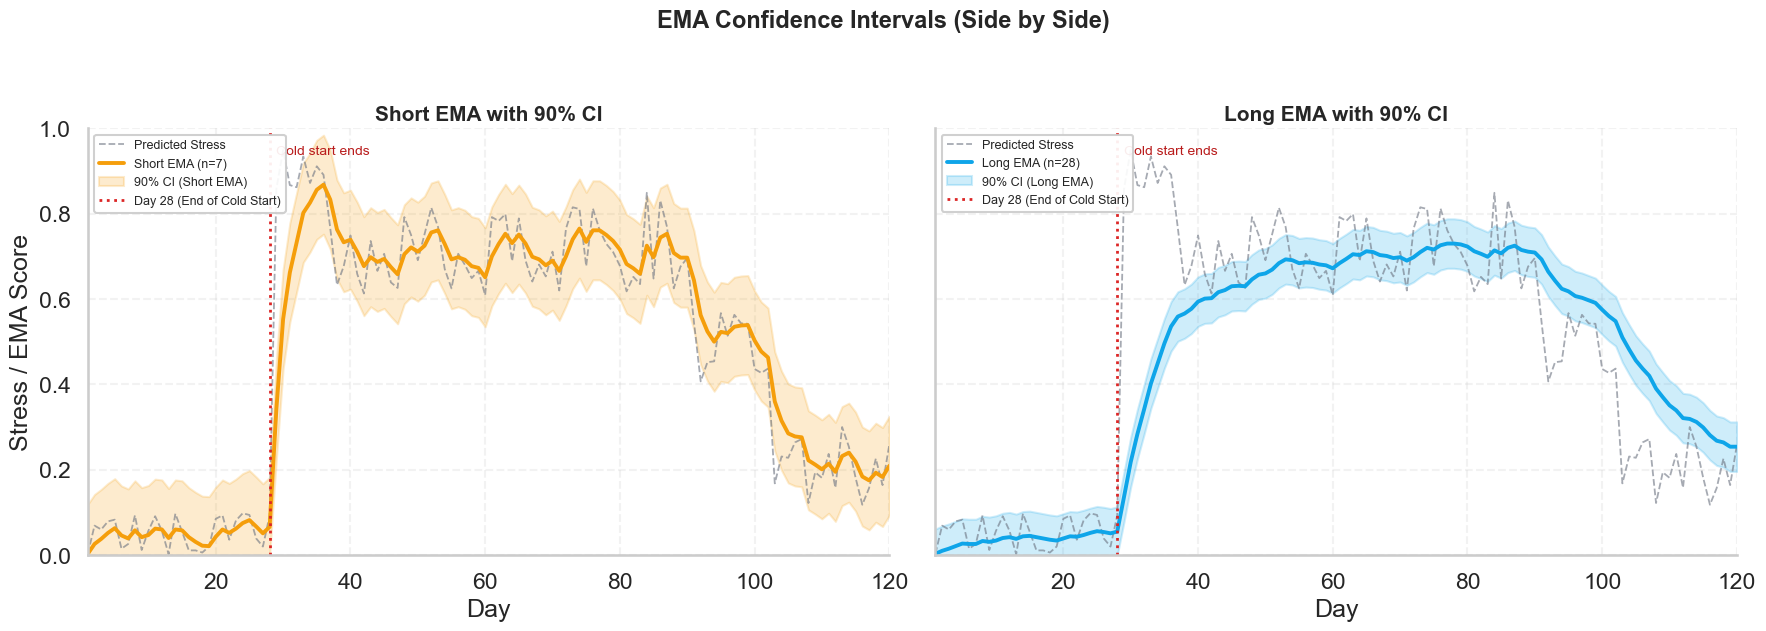

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style='whitegrid', context='talk')

# Ensure EMA columns exist
if 'short_ema' not in mock_data_1.columns or 'long_ema' not in mock_data_1.columns:
    short_n = 7
    long_n = 28
    short_ema_values = []
    long_ema_values = []
    prev_short_ema = None
    prev_long_ema = None

    for _, row in mock_data_1.iterrows():
        short_ema, long_ema = calculate_dual_ema(
            row['predicted_stress'],
            prev_short_ema=prev_short_ema,
            prev_long_ema=prev_long_ema,
            short_n=short_n,
            long_n=long_n
        )
        short_ema_values.append(short_ema)
        long_ema_values.append(long_ema)
        prev_short_ema = short_ema
        prev_long_ema = long_ema

    mock_data_1['short_ema'] = short_ema_values
    mock_data_1['long_ema'] = long_ema_values

# CI settings (sigma uses RMSE)
sigma = 0.1542
short_n = 7
long_n = 28
short_ci = calculate_confidence(sigma=sigma, n=short_n, confidence_level=0.90)
long_ci = calculate_confidence(sigma=sigma, n=long_n, confidence_level=0.90)
# print(f"Short EMA CI: ±{short_ci}, Long EMA CI: ±{long_ci}")

short_lower = np.clip(mock_data_1['short_ema'] - short_ci, 0, 1)
short_upper = np.clip(mock_data_1['short_ema'] + short_ci, 0, 1)
long_lower = np.clip(mock_data_1['long_ema'] - long_ci, 0, 1)
long_upper = np.clip(mock_data_1['long_ema'] + long_ci, 0, 1)

# Side-by-side CI plots
fig, axes = plt.subplots(1, 2, figsize=(18, 6.2), sharex=True, sharey=True)

# Left: Short EMA CI
axes[0].plot(
    mock_data_1['day'],
    mock_data_1['predicted_stress'],
    label='Predicted Stress',
    linestyle='--',
    linewidth=1.3,
    color='#6B7280',
    alpha=0.6
)
axes[0].plot(
    mock_data_1['day'],
    mock_data_1['short_ema'],
    label=f'Short EMA (n={short_n})',
    linewidth=2.8,
    color='#F59E0B'
 )
axes[0].fill_between(
    mock_data_1['day'],
    short_lower,
    short_upper,
    color='#F59E0B',
    alpha=0.20,
    label='90% CI (Short EMA)'
)
axes[0].axvline(x=28, color='#DC2626', linestyle=':', linewidth=2, label='Day 28 (End of Cold Start)')
axes[0].text(29, 0.96, 'Cold start ends', color='#B91C1C', fontsize=10, va='top')
axes[0].set_title('Short EMA with 90% CI', fontsize=15, weight='semibold')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Stress / EMA Score')
axes[0].set_xlim(1, 120)
axes[0].set_ylim(0, 1)
axes[0].grid(alpha=0.25, linestyle='--')
axes[0].legend(loc='upper left', frameon=True, framealpha=0.92, fontsize=9)

# Right: Long EMA CI
axes[1].plot(
    mock_data_1['day'],
    mock_data_1['predicted_stress'],
    label='Predicted Stress',
    linestyle='--',
    linewidth=1.3,
    color='#6B7280',
    alpha=0.6
)
axes[1].plot(
    mock_data_1['day'],
    mock_data_1['long_ema'],
    label=f'Long EMA (n={long_n})',
    linewidth=2.8,
    color='#0EA5E9'
 )
axes[1].fill_between(
    mock_data_1['day'],
    long_lower,
    long_upper,
    color='#0EA5E9',
    alpha=0.20,
    label='90% CI (Long EMA)'
)
axes[1].axvline(x=28, color='#DC2626', linestyle=':', linewidth=2, label='Day 28 (End of Cold Start)')
axes[1].text(29, 0.96, 'Cold start ends', color='#B91C1C', fontsize=10, va='top')
axes[1].set_title('Long EMA with 90% CI', fontsize=15, weight='semibold')
axes[1].set_xlabel('Day')
axes[1].grid(alpha=0.25, linestyle='--')
axes[1].legend(loc='upper left', frameon=True, framealpha=0.92, fontsize=9)

sns.despine()
fig.suptitle('EMA Confidence Intervals (Side by Side)', fontsize=17, weight='bold', y=1.03)
plt.tight_layout()
plt.show()

In [27]:
# Display CI values used in the two EMA CI plots
sigma = 0.1542  # RMSE
short_ci = calculate_confidence(sigma=sigma, n=7, confidence_level=0.90)
long_ci = calculate_confidence(sigma=sigma, n=28, confidence_level=0.90)

print(f"Sigma (RMSE): {sigma:.3f}")
print(f"Short EMA 90% CI (n=7): +/-{short_ci:.3f}")
print(f"Long EMA 90% CI (n=28): +/-{long_ci:.3f}")

Sigma (RMSE): 0.154
Short EMA 90% CI (n=7): +/-0.116
Long EMA 90% CI (n=28): +/-0.058


# Burnout Matrix

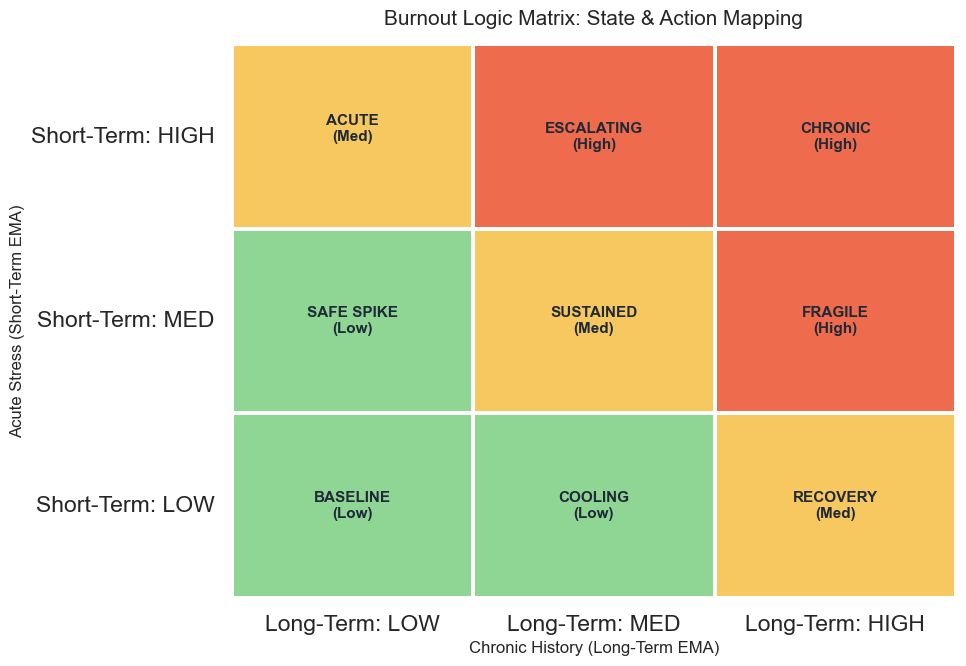

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

# 1. Map our 9 states to numeric values for coloring
# 0 = Low (Green), 1 = Med (Amber), 2 = High (Coral)
logic_values = np.array([
    [1, 2, 2],  # (Acute, Escalating, Chronic)
    [0, 1, 2],  # (Safe Spike, Sustained, Fragile)
    [0, 0, 1]   # (Baseline, Cooling, Recovery)
])

# 2. Define the labels for the cells
labels = np.array([
    ["ACUTE\n(Med)\n", "ESCALATING\n(High)", "CHRONIC\n(High)"],
    ["SAFE SPIKE\n(Low)", "SUSTAINED\n(Med)", "FRAGILE\n(High)"],
    ["BASELINE\n(Low)", "COOLING\n(Low)", "RECOVERY\n(Med)"]
])

# 3. Use a softer, clearer custom palette (low -> medium -> high)
burnout_cmap = ListedColormap(["#8FD694", "#F6C85F", "#EE6C4D"])

plt.figure(figsize=(10, 7))
ax = sns.heatmap(
    logic_values,
    annot=labels,
    fmt="",
    cmap=burnout_cmap,
    cbar=False,
    linewidths=1.5,
    linecolor="#FFFFFF",
    xticklabels=["Long-Term: LOW", "Long-Term: MED", "Long-Term: HIGH"],
    yticklabels=["Short-Term: HIGH", "Short-Term: MED", "Short-Term: LOW"],
    annot_kws={"fontsize": 11, "fontweight": "semibold", "color": "#1F2937"}
)

plt.title("Burnout Logic Matrix: State & Action Mapping", fontsize=15, pad=14)
plt.xlabel("Chronic History (Long-Term EMA)", fontsize=12)
plt.ylabel("Acute Stress (Short-Term EMA)", fontsize=12)

# Keep y-axis labels horizontal for readability
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()